# Level 1, Task 2: Data Cleaning and preprocessing

## 1.1)Introduction

Data cleaning and preprocessing form the foundation of any successful data analysis or machine learning project. In raw form, data is often incomplete, inconsistent, or filled with errors that can mislead results or reduce model performance. Before deriving insights or building predictive models, it is crucial to ensure that the dataset is accurate, reliable, and properly structured.
This project focuses on the systematic process of cleaning and preprocessing data to enhance its quality and readiness for analysis. The tasks include handling missing values, removing duplicates, detecting and managing outliers, encoding categorical variables, and scaling numerical features.

## 1.2)Problem Statement

Raw data collected from various sources often contains noise, inconsistencies, and irrelevant information, making it unsuitable for direct use in analytics or machine learning. Problems such as missing values, duplicated records, incorrect data types, and inconsistent formatting can distort analytical results and lead to poor model performance. Therefore, there is a need for a structured approach to identify and resolve these data quality issues efficiently.

## 1.3)Objective

The main objective of this project is to perform comprehensive data cleaning and preprocessing to prepare the dataset for accurate analysis and modeling.
Specific objectives include:

* To identify and handle missing, null, and duplicate values.

* To detect and treat outliers that may skew results.

* To convert categorical data into numerical formats through encoding techniques.

* To standardize and normalize numerical variables for consistency.

* To ensure the dataset is ready for exploratory data analysis (EDA) and machine learning modeling with improved quality and reliability.

## 2) Import libraries

In [31]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 3)Load the datasets

In [32]:
# Load the data
df_train = pd.read_csv('/content/churn-bigml-80.csv')
df_test = pd.read_csv('/content/churn-bigml-20.csv')

## 4)Checking the Data

In [33]:
# shape of the two datasets
print(df_train.shape)
df_test.shape

(2666, 20)


(667, 20)

In [34]:
# preview the first 5 rows for each dataset
df_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [35]:
df_test.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [36]:
# preview the last 5 rows for each dataset
df_train.tail()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
2661,SC,79,415,No,No,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
2665,TN,74,415,No,Yes,25,234.4,113,39.85,265.9,82,22.60,241.4,77,10.86,13.7,4,3.70,0,False


In [37]:
df_test.tail()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
662,WI,114,415,No,Yes,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2,False
663,AL,106,408,No,Yes,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1,False
664,VT,60,415,No,No,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3,False
665,WV,159,415,No,No,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1,False
666,CT,184,510,Yes,No,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [38]:
# Summary of the dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

there is one boolean column, 3 object columns and 16 numerical columns.

In [39]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

## 5)Data cleaning

### 5.1)Checking for missing values

In [40]:
df_train.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


there are no missing columns in the df_train dataset

In [41]:
df_test.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


there are no missing columns in the df_test dataset

### 5.2) Checking for duplicates


In [42]:
df_train.duplicated().sum()

np.int64(0)

there are no duplicated rows in the df_train dataset

In [43]:
df_test.duplicated().sum()

np.int64(0)

there are no duplicated rows in the df_test dataset

## 6) Outlier detection

In [44]:
num_cols = df_train.select_dtypes(include=np.number).columns
cat_cols = df_train.select_dtypes(include='object').columns

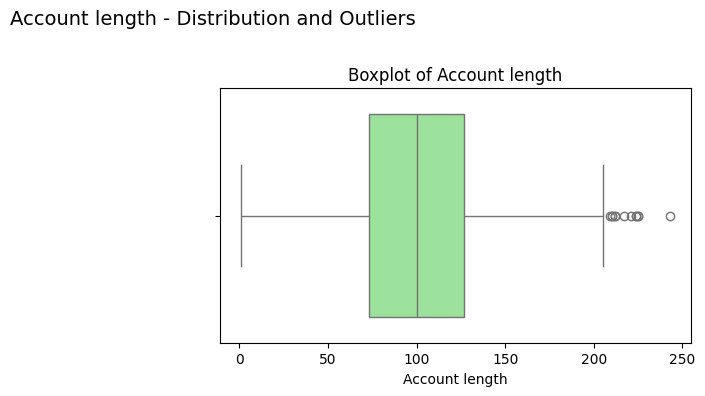

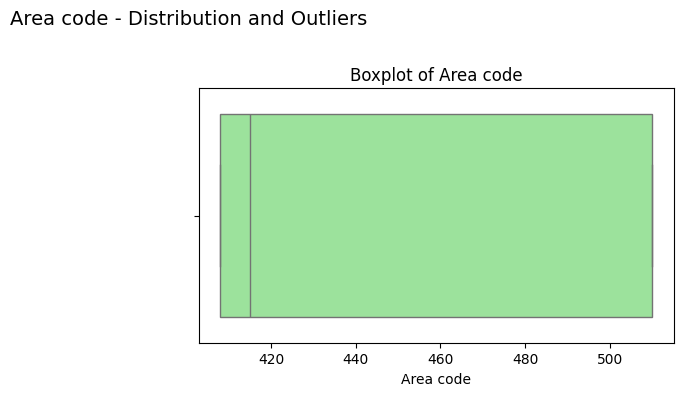

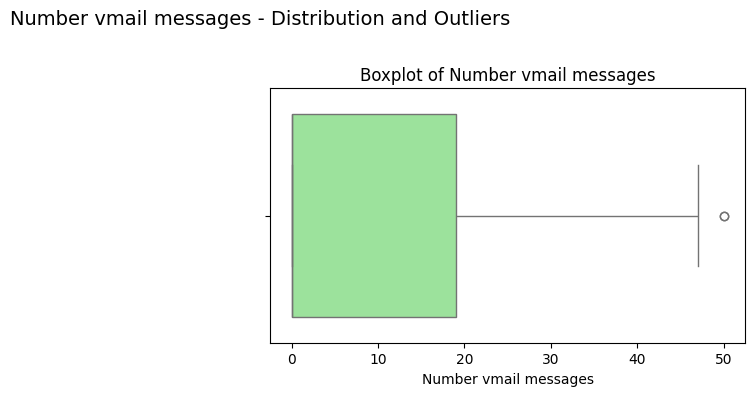

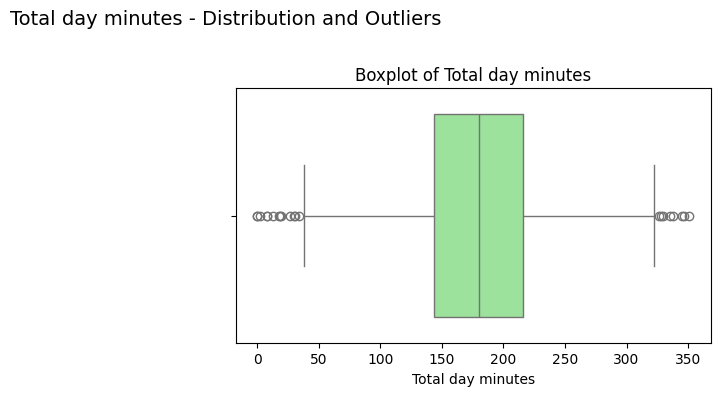

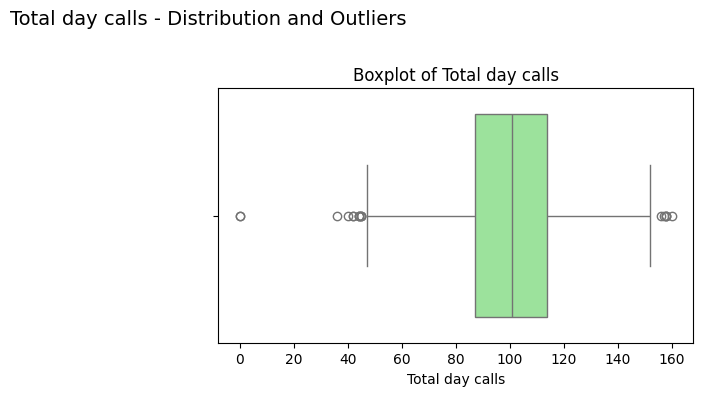

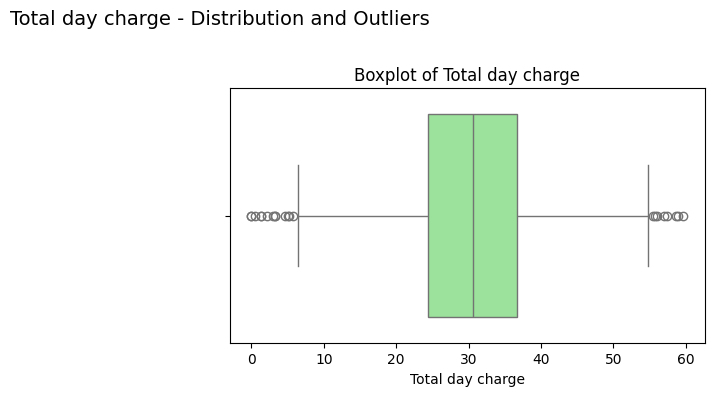

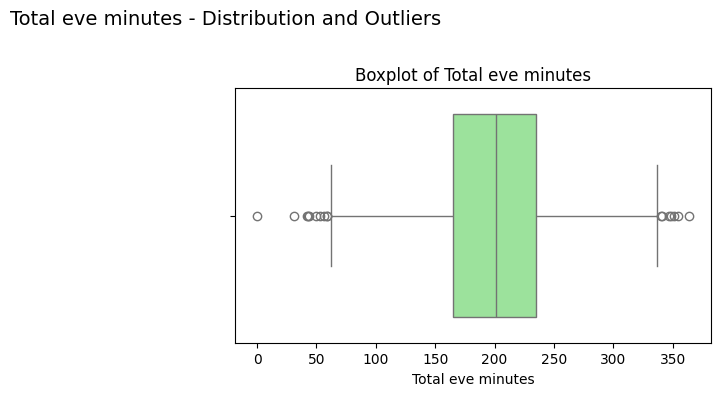

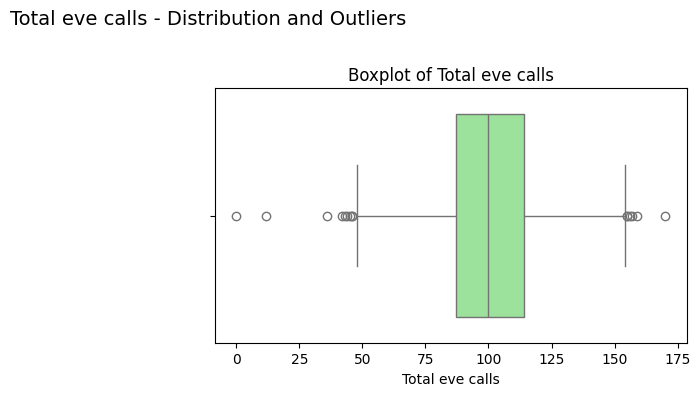

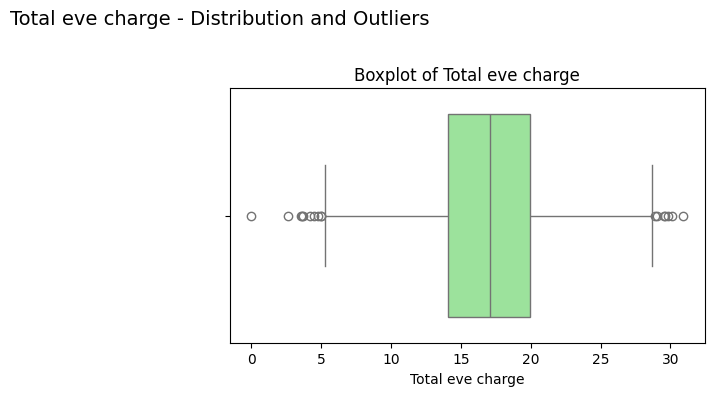

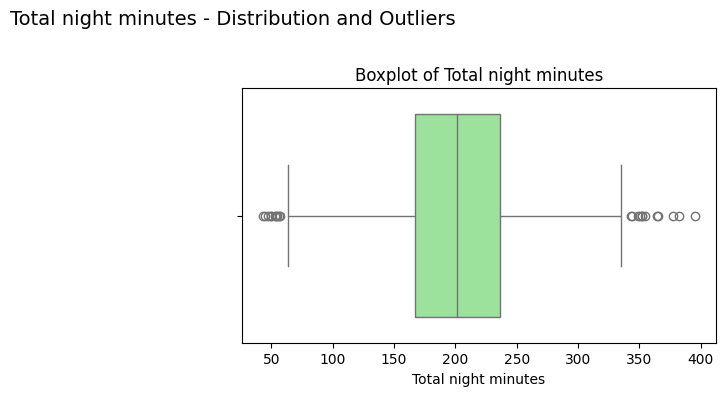

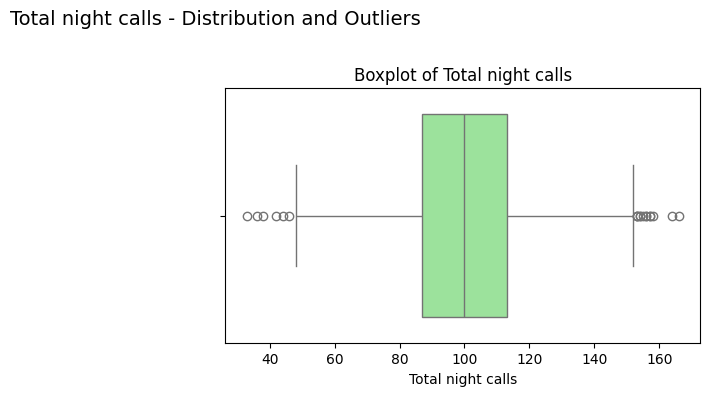

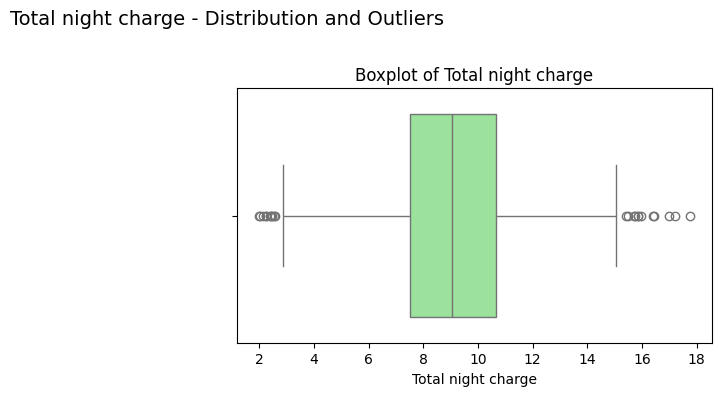

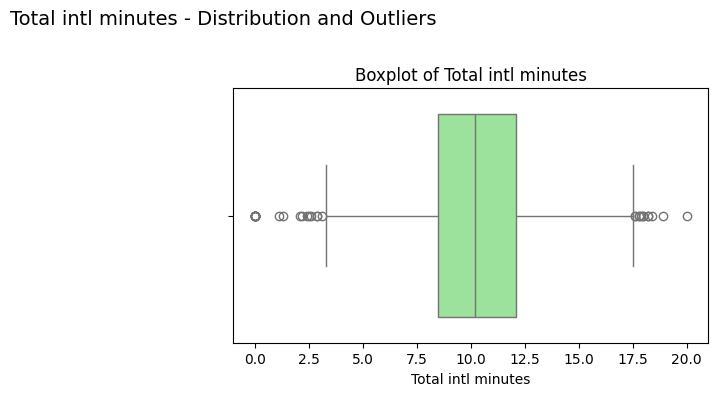

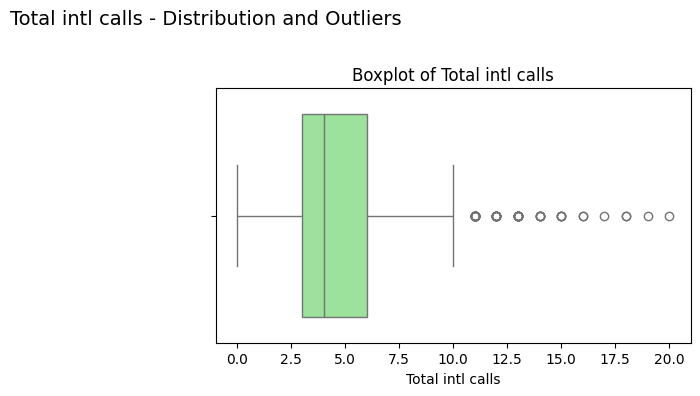

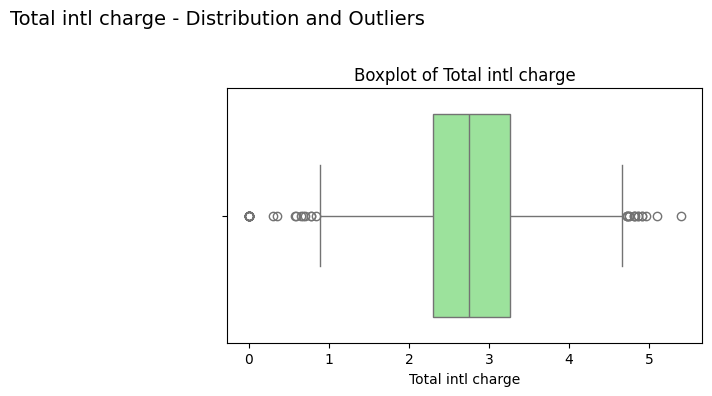

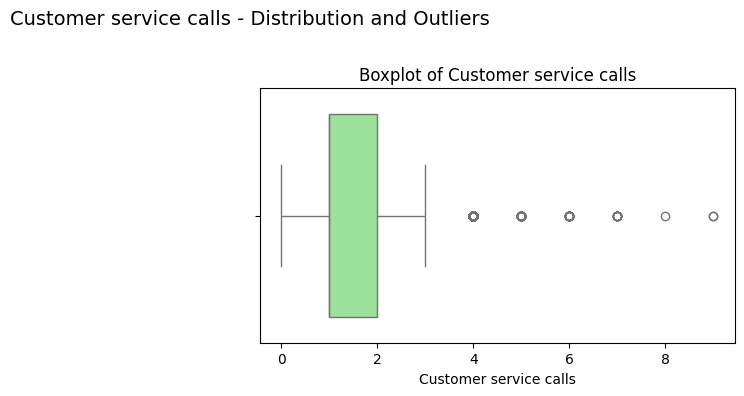

In [45]:
# Loop through each numerical column
for col in num_cols:
    plt.figure(figsize=(10, 4))  # Create a figure for each column with two subplots

    # --- Boxplot ---
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_train[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    # --- Layout & display ---
    plt.suptitle(f"{col.capitalize()} - Distribution and Outliers", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

There are Outliers in some columns

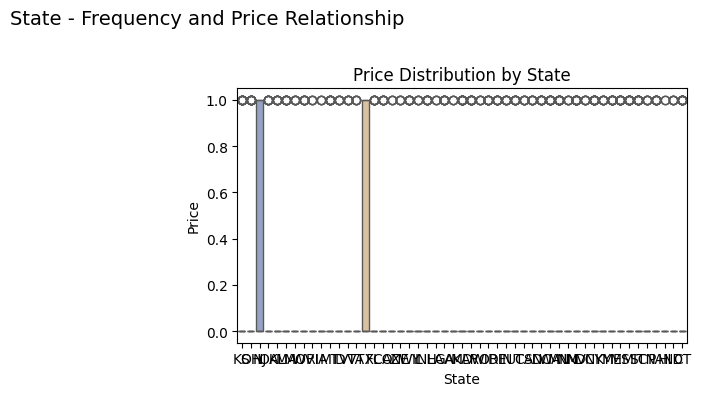

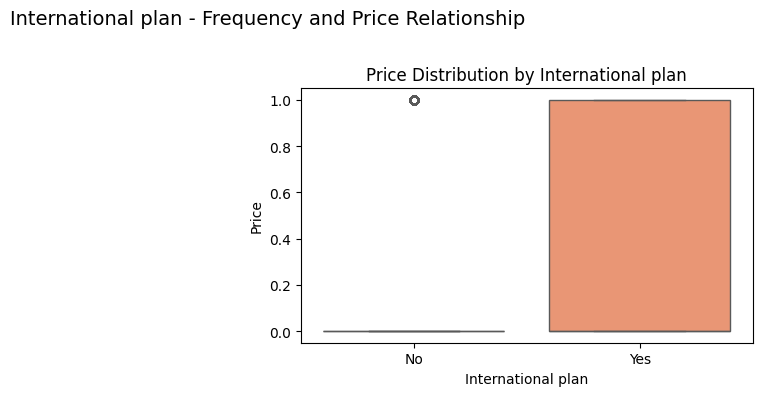

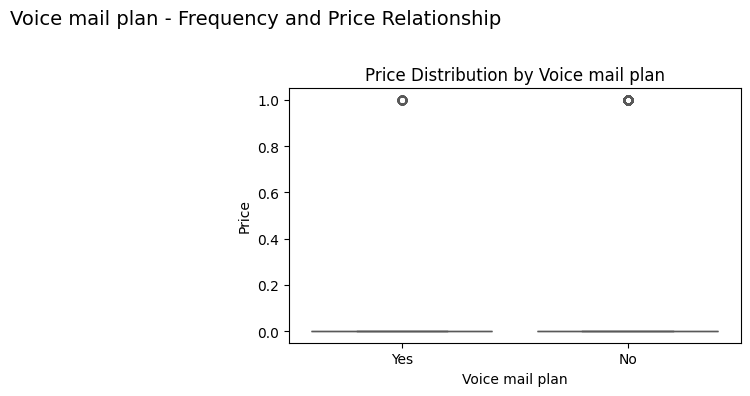

In [46]:
for col in cat_cols:
    plt.figure(figsize=(10, 4))


    # --- Boxplot (category vs Churn) ---
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_train[col], y=df_train['Churn'], palette='Set2')
    plt.title(f"Price Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Price")

    # --- Layout ---
    plt.suptitle(f"{col.capitalize()} - Frequency and Price Relationship", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Its hard to ascertain the outliers in the test dataset

In [47]:
num_cols = df_test.select_dtypes(include=np.number).columns
cat_cols = df_test.select_dtypes(include='object').columns

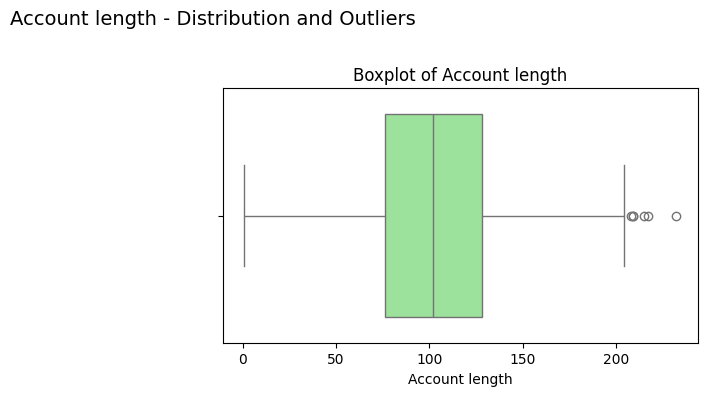

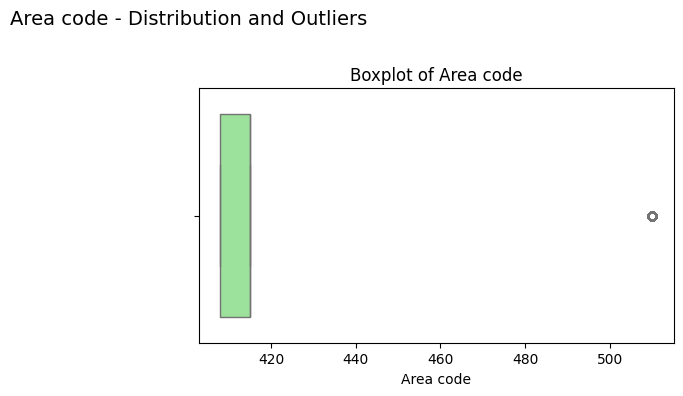

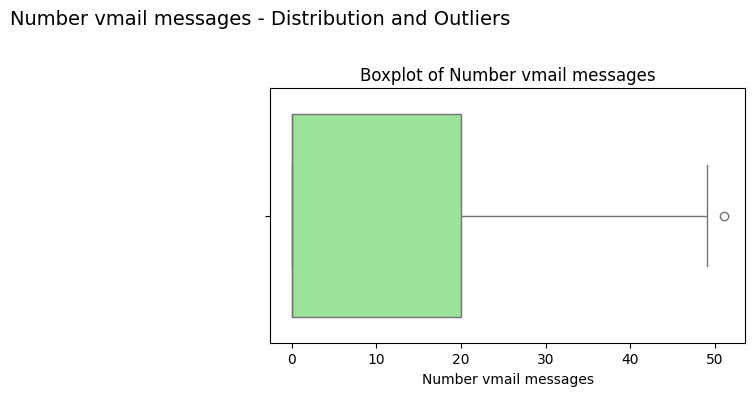

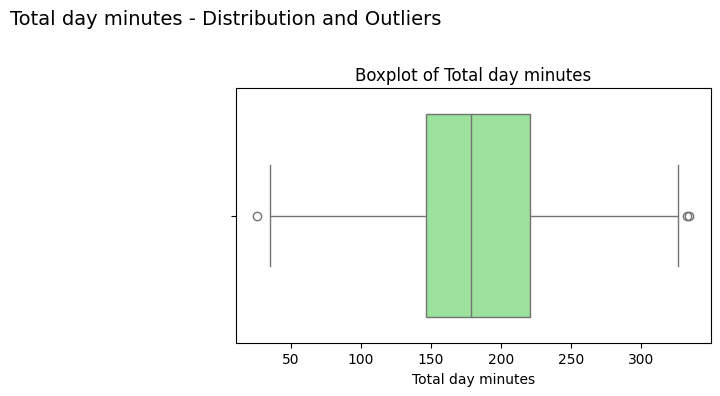

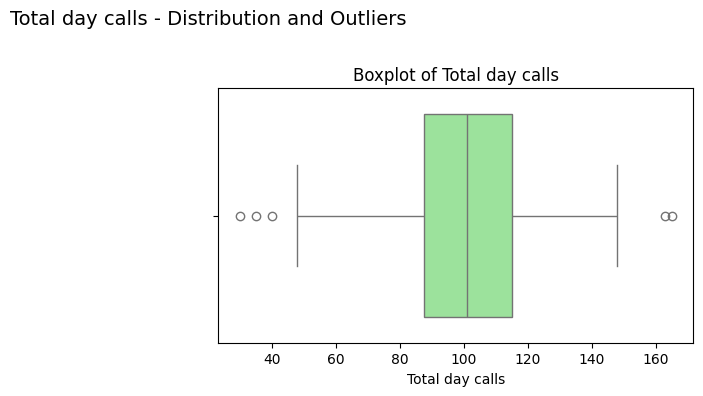

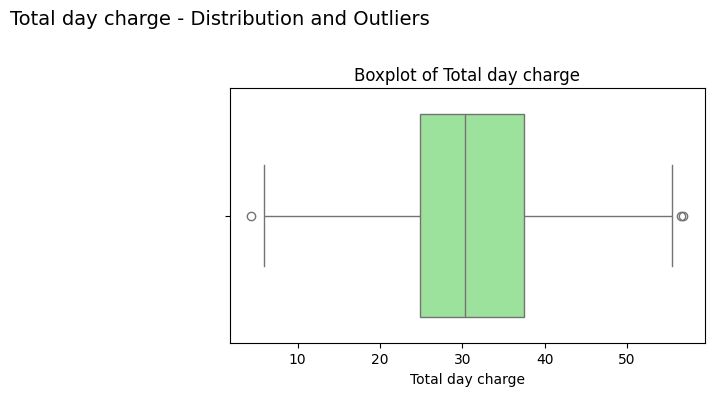

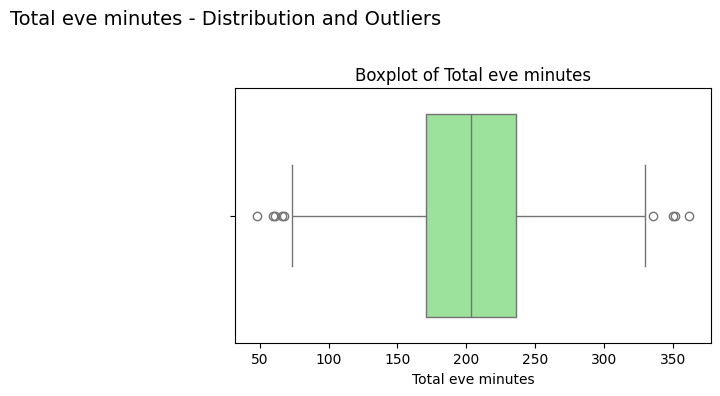

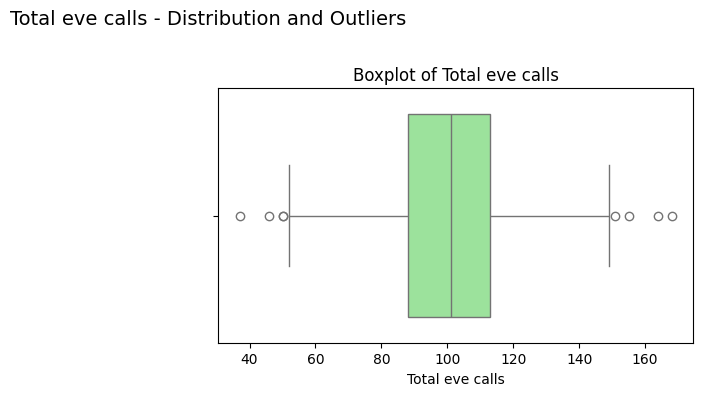

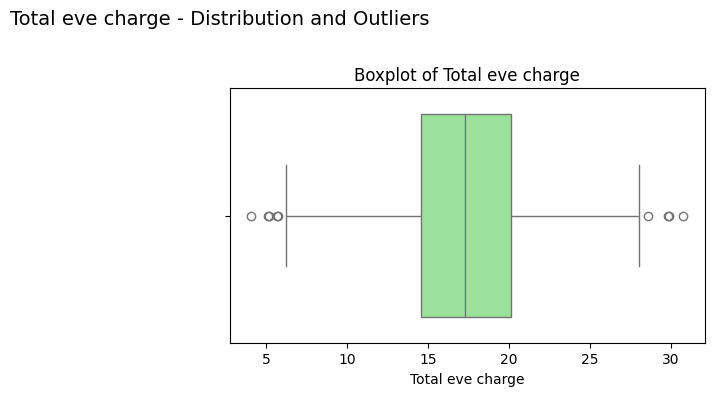

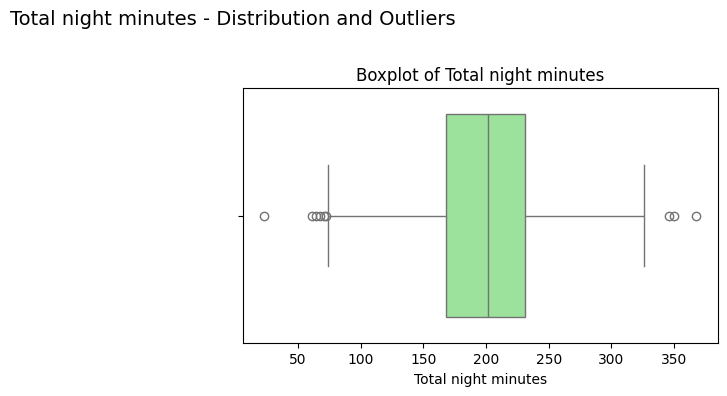

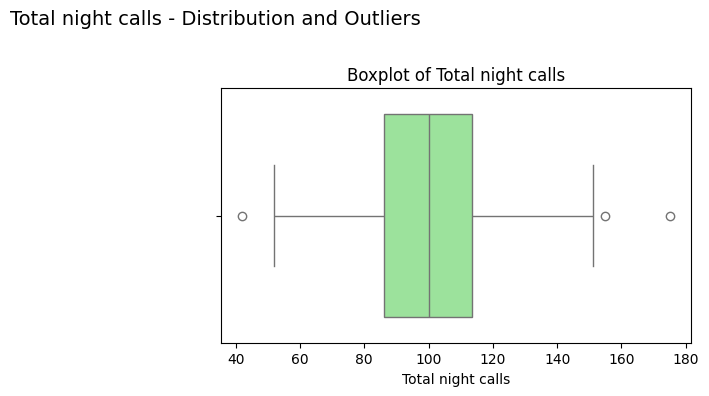

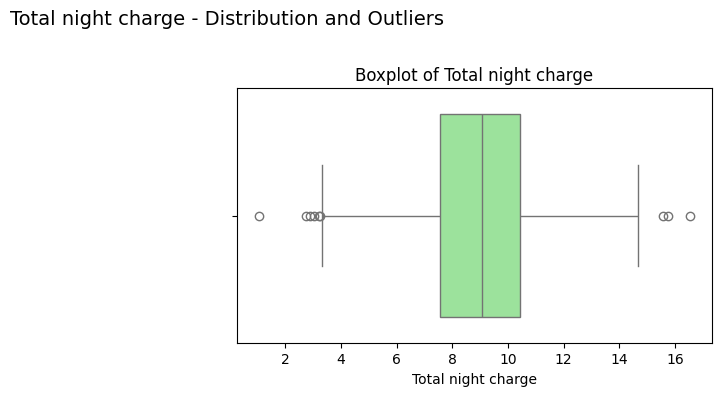

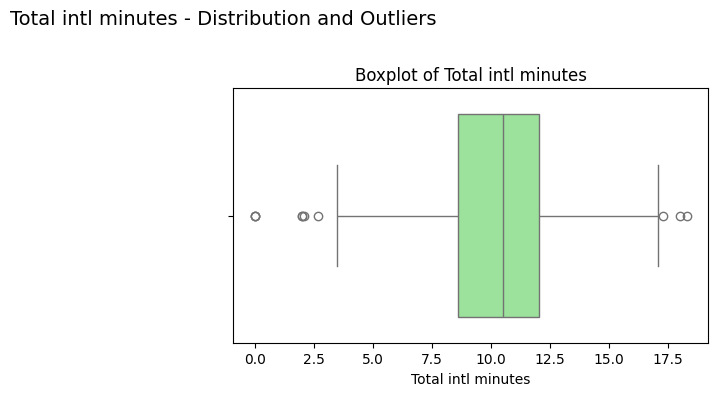

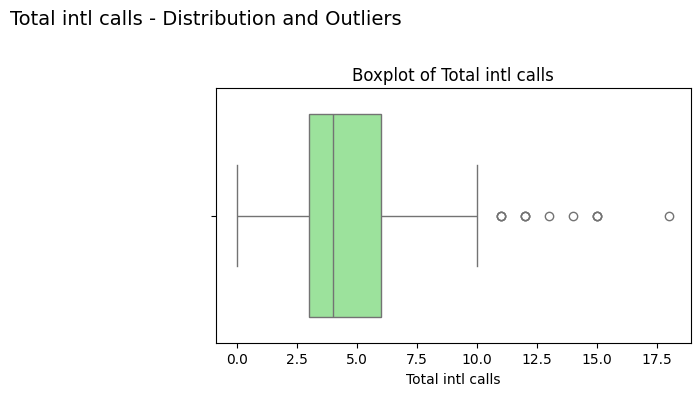

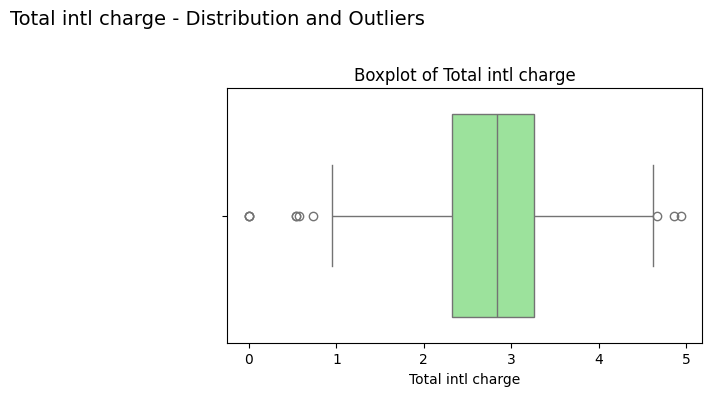

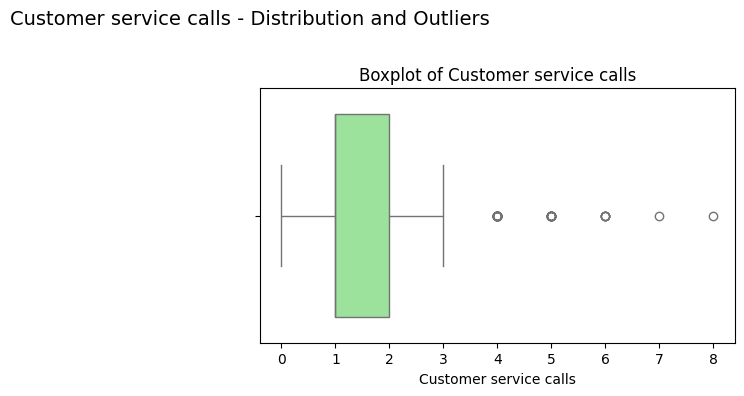

In [48]:
# Loop through each numerical column
for col in num_cols:
    plt.figure(figsize=(10, 4))  # Create a figure for each column with two subplots

    # --- Boxplot ---
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_test[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    # --- Layout & display ---
    plt.suptitle(f"{col.capitalize()} - Distribution and Outliers", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show

some columns have outliers

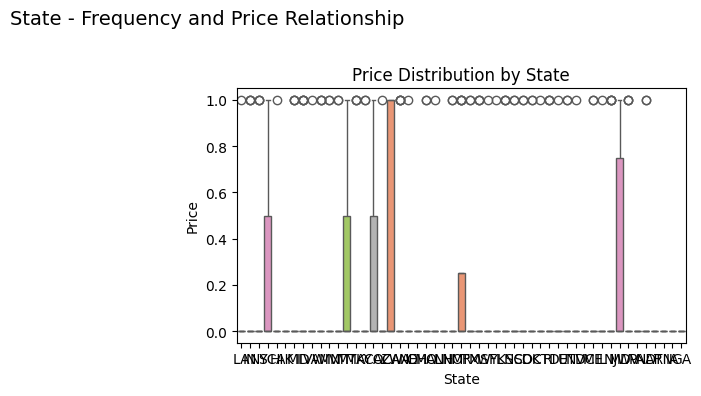

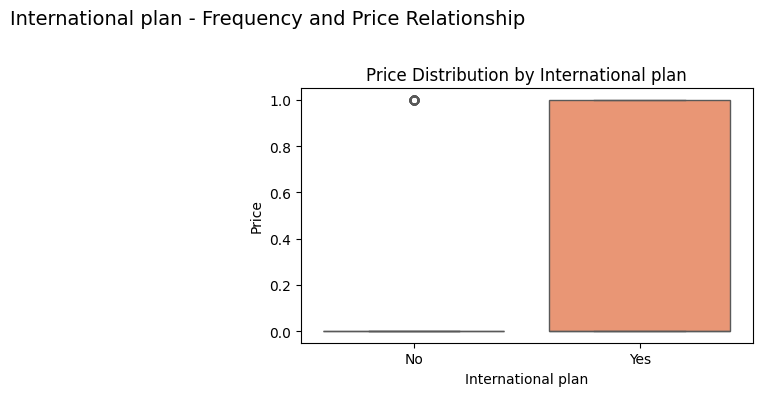

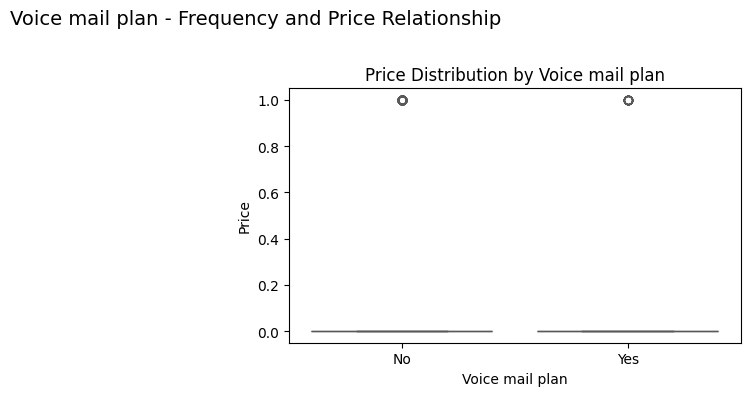

In [49]:
for col in cat_cols:
    plt.figure(figsize=(10, 4))


    # --- Boxplot (category vs Churn) ---
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_test[col], y=df_test['Churn'], palette='Set2')
    plt.title(f"Price Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Price")

    # --- Layout ---
    plt.suptitle(f"{col.capitalize()} - Frequency and Price Relationship", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Its hard to ascertain the outliers in the test dataset

## 7)Removing the outliers

In [50]:
# from the train dataset
for col in num_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the dataset
    df_train = df_train[(df_train[col] >= lower_bound) & (df_train[col] <= upper_bound)]
    print(f"Outliers removed from {col}")
print("✅ Outliers removed successfully!")
print("Remaining data shape:", df_train.shape)


Outliers removed from Account length
Outliers removed from Area code
Outliers removed from Number vmail messages
Outliers removed from Total day minutes
Outliers removed from Total day calls
Outliers removed from Total day charge
Outliers removed from Total eve minutes
Outliers removed from Total eve calls
Outliers removed from Total eve charge
Outliers removed from Total night minutes
Outliers removed from Total night calls
Outliers removed from Total night charge
Outliers removed from Total intl minutes
Outliers removed from Total intl calls
Outliers removed from Total intl charge
Outliers removed from Customer service calls
✅ Outliers removed successfully!
Remaining data shape: (2243, 20)


In [51]:
# from the test dataset
for col in num_cols:
    Q1 = df_test[col].quantile(0.25)
    Q3 = df_test[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the dataset
    df_test = df_test[(df_test[col] >= lower_bound) & (df_test[col] <= upper_bound)]
    print(f"Outliers removed from {col}")
print("✅ Outliers removed successfully!")
print("Remaining data shape:", df_test.shape)

Outliers removed from Account length
Outliers removed from Area code
Outliers removed from Number vmail messages
Outliers removed from Total day minutes
Outliers removed from Total day calls
Outliers removed from Total day charge
Outliers removed from Total eve minutes
Outliers removed from Total eve calls
Outliers removed from Total eve charge
Outliers removed from Total night minutes
Outliers removed from Total night calls
Outliers removed from Total night charge
Outliers removed from Total intl minutes
Outliers removed from Total intl calls
Outliers removed from Total intl charge
Outliers removed from Customer service calls
✅ Outliers removed successfully!
Remaining data shape: (410, 20)


## 8)Data preprocessing

In [52]:
df_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False


In [53]:
# Encoding the Categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_train['State'] = le.fit_transform(df_train['State'])
df_train['International plan'] = le.fit_transform(df_train['International plan'])
df_train['Voice mail plan'] = le.fit_transform(df_train['Voice mail plan'])
df_train['Churn'] = le.fit_transform(df_train['Churn'])


In [54]:
df_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
5,1,118,510,1,0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,0


In [55]:
df_test.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
5,AK,36,408,No,Yes,30,146.3,128,24.87,162.5,80,13.81,129.3,109,5.82,14.5,6,3.92,0,False
6,MI,65,415,No,No,0,211.3,120,35.92,162.6,122,13.82,134.7,118,6.06,13.2,5,3.56,3,False
8,VA,10,408,No,No,0,186.1,112,31.64,190.2,66,16.17,282.8,57,12.73,11.4,6,3.08,2,False
11,HI,85,415,No,No,0,235.8,109,40.09,157.2,94,13.36,188.2,99,8.47,12.0,3,3.24,0,False


In [56]:
# Encoding the Categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_test['State'] = le.fit_transform(df_test['State'])
df_test['International plan'] = le.fit_transform(df_test['International plan'])
df_test['Voice mail plan'] = le.fit_transform(df_test['Voice mail plan'])
df_test['Churn'] = le.fit_transform(df_test['Churn'])

In [57]:
df_test.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
3,40,111,415,0,0,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,0
5,0,36,408,0,1,30,146.3,128,24.87,162.5,80,13.81,129.3,109,5.82,14.5,6,3.92,0,0
6,22,65,415,0,0,0,211.3,120,35.92,162.6,122,13.82,134.7,118,6.06,13.2,5,3.56,3,0
8,45,10,408,0,0,0,186.1,112,31.64,190.2,66,16.17,282.8,57,12.73,11.4,6,3.08,2,0
11,11,85,415,0,0,0,235.8,109,40.09,157.2,94,13.36,188.2,99,8.47,12.0,3,3.24,0,0


## 9)Standardizing the dataset

In [58]:
from sklearn.preprocessing import StandardScaler


# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the numeric columns
df_train = scaler.fit_transform(df_train)

# Transform the test dataset
df_test = scaler.transform(df_test)

print("✅ Dataset standardized successfully!")

✅ Dataset standardized successfully!
